# 2.5 Weather

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [13]:
#download the weather images and put them in a directory
path = path = r"C:\Users\cschw\OneDrive\Desktop\Machine Learning\Weather Archive\Multi-class Weather Dataset"

folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [15]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [17]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [54]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 16, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 490ms/step - accuracy: 0.8888 - loss: 0.0445 - val_accuracy: 0.8348 - val_loss: 0.0708
Epoch 2/16
 1/28 ━━━━━━━━━━━━━━━━━━━━ 10s 397ms/step - accuracy: 0.7812 - loss: 0.0837

C:\Users\cschw\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7812 - loss: 0.0837 - val_accuracy: 0.8304 - val_loss: 0.0649
Epoch 3/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 508ms/step - accuracy: 0.9074 - loss: 0.0334 - val_accuracy: 0.8393 - val_loss: 0.0666
Epoch 4/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9375 - loss: 0.0274 - val_accuracy: 0.8304 - val_loss: 0.0711
Epoch 5/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 531ms/step - accuracy: 0.9376 - loss: 0.0223 - val_accuracy: 0.8884 - val_loss: 0.0468
Epoch 6/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 0.8884 - val_loss: 0.0458
Epoch 7/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 497ms/step - accuracy: 0.9252 - loss: 0.0286 - val_accuracy: 0.8705 - val_loss: 0.0513
Epoch 8/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9375 - loss: 0.0196 - val_accuracy: 0.8304 - val_loss: 0.0702
Epoch 9/16
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 501ms/step - accuracy: 0.8882 - loss: 0.0442 - val_accuracy: 0.7902 - val_

In [55]:
results = pd.DataFrame(model.history.history)

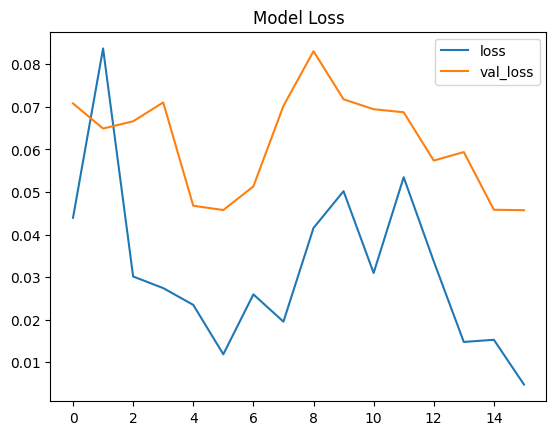

In [56]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

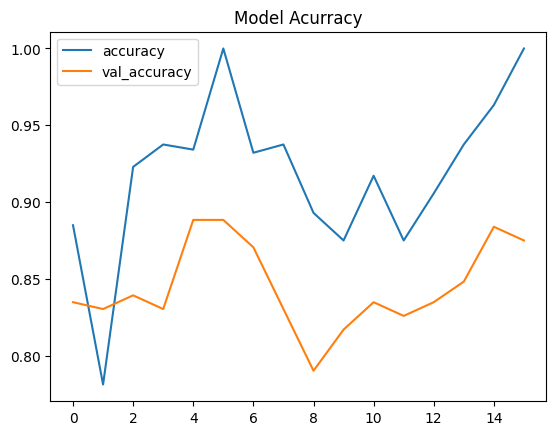

In [57]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [58]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 1.0, Val_Accuracy: 0.875
Loss: 0.004795477259904146, Val_Loss: 0.04573047161102295


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


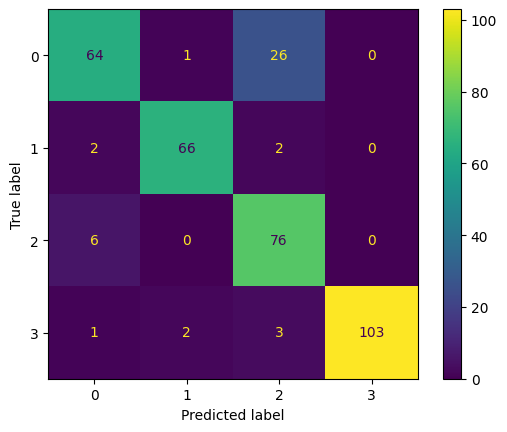

In [59]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [60]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


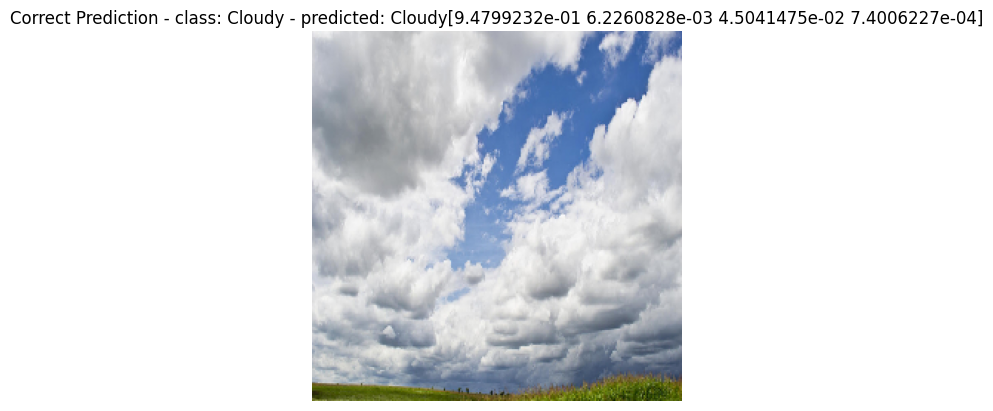

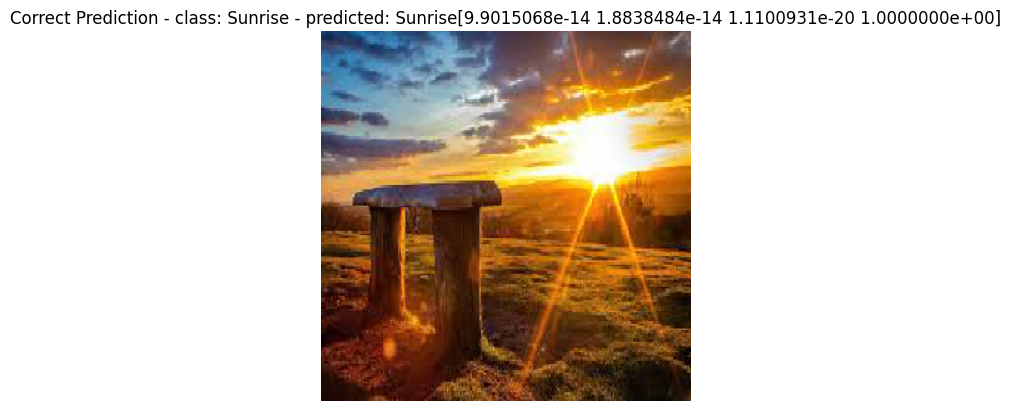

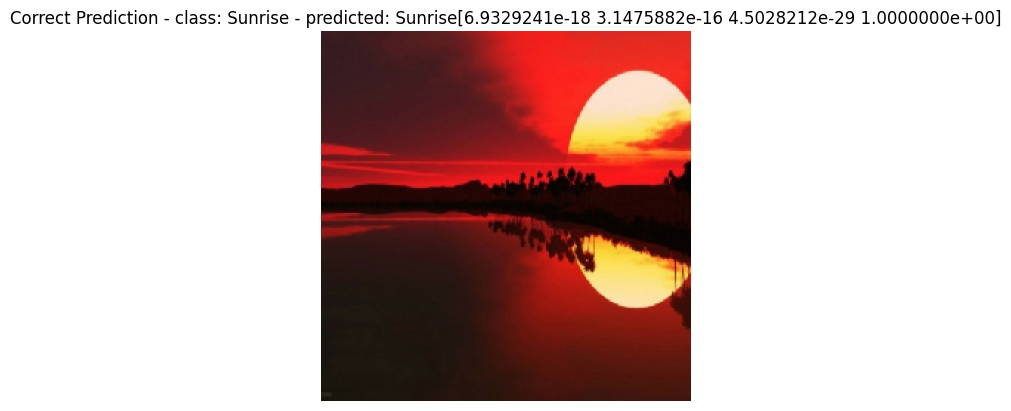

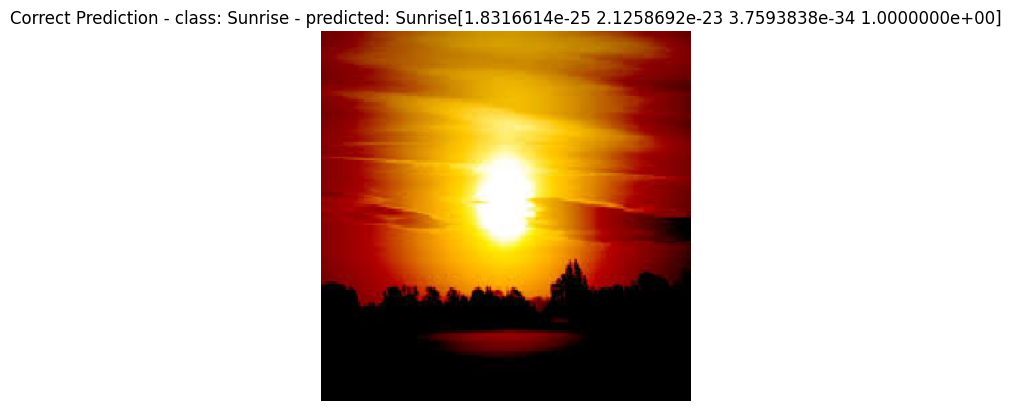

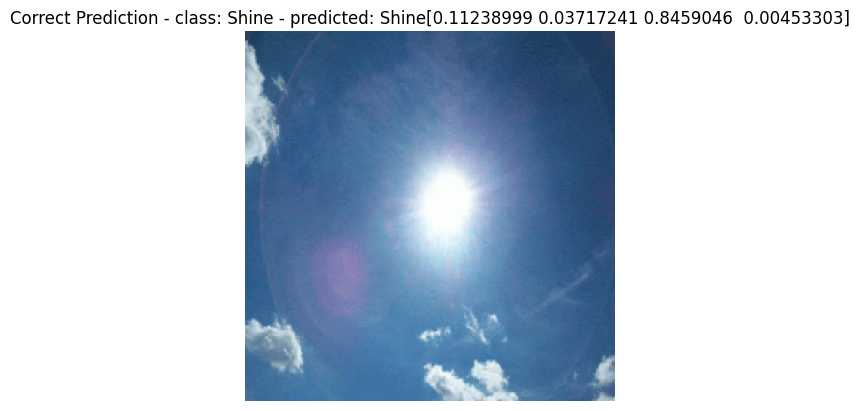

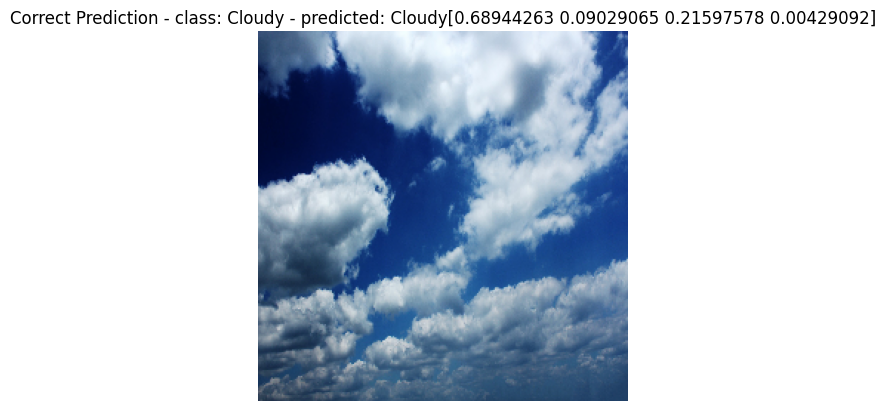

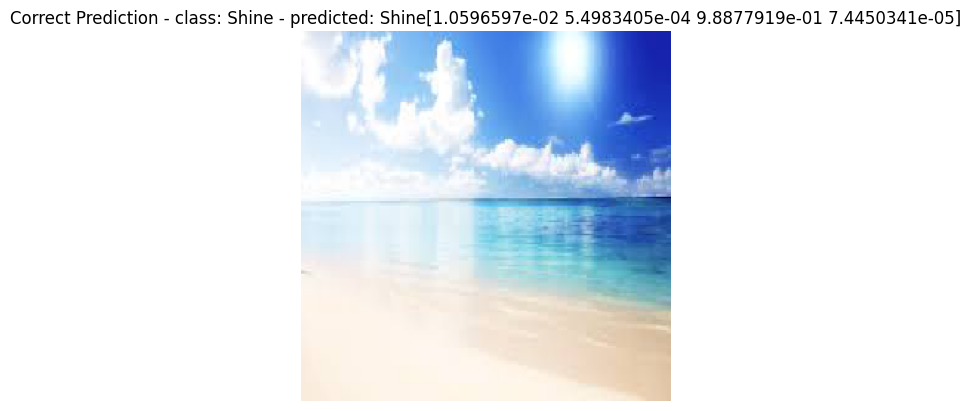

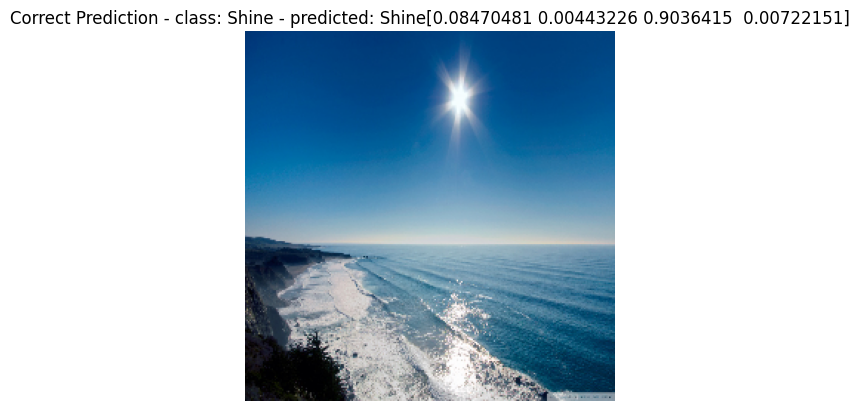

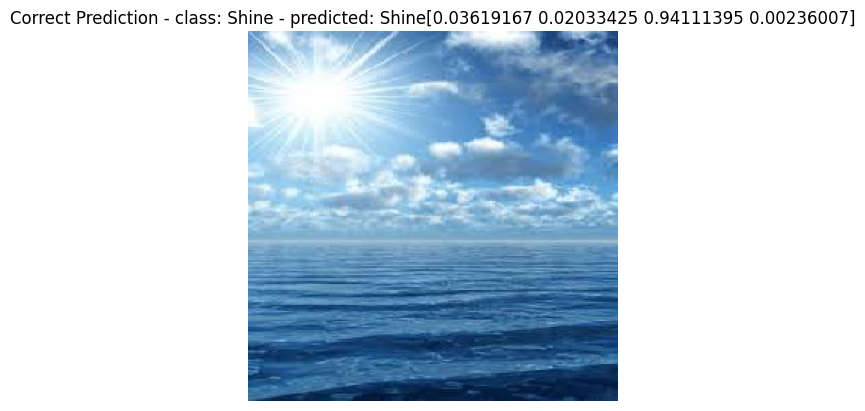

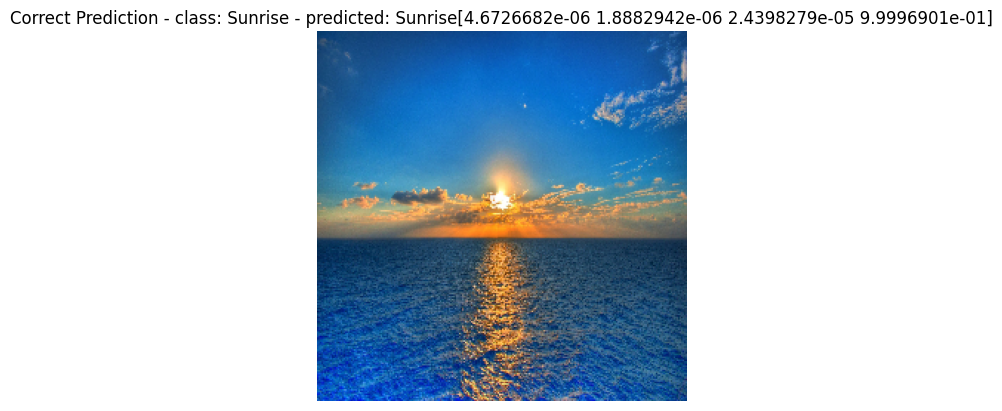

In [61]:
predict_one(model, 10) #<--you can show multiple pictures with this command. Just fill in the number you want to see.